# eBay E-commerce Data Analysis Project(eBay平台爬虫数据抓取的数据集(公共))

## 1.Project Overview 项目概述
    本项目基于eBay平台 电商数据,进行了以下分析:
        - 品牌销售TOP10
        - 发货国家分析
        - 价格区间销量
        - 价格与销量散点图
        - top10热销产品
        - 品牌平均价格
        - 品牌市场份额

## 2.数据字段说明
    字段包含:
        - brand 品牌
        - item_name 商品名称
        - rating 评论数量
        - comments 商品情况(全新/二手/99新)
        - all_price($) 是爬虫抓取的价格一栏 是脏数据 里面包含了 123 to 456 经过PowerBI里面的Power Query处理过了
        - price_min 处理后的最低价格
        - price_max 处理后的最高价格
        - avg_price 处理后的平均价格
        - shipping_cost_num 处理后的运费
        - shipping_cost(+$) 是脏数据 里面包含了 Free None Shipping 经过 PowerBI里面的Power Query处理了
        - sold_quantity 销量 是脏数据 里面包含了 None 导致类型成了文本 经过 PowerBI里面的Power Query处理了
        - view_quantity 浏览量 是脏数据 里面包含了 None 导致类型成了文本 经过 PowerBI里面的Power Query处理了

## 3.数据清洗

### 3.1 导入包

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### 3.2 封装重复出现的可视化部分

In [ ]:
#封装 plt 画图部分
def pltModulePackaging(title,xlabel,ylabel,rotation = 45):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation = rotation)
    plt.tight_layout()

    plt.show()

### 3.3 数据清洗过程
    在分析前先对数据进行预处理:
        - 处理缺失值
        - 删除空评论、删除重复评论

In [ ]:
ec = pd.read_csv("/menu/ProjectSet/EbayEcommerceAnalysisProject/DataSet/ebay E-Commerce scrapped Dataset.csv")

#数据清洗
# print(ec.head()) #显示有没有拿到数据 并且可以看到字段名
# print(ec.shape) #显示数据集里有多少数据
# print(ec.isnull().sum()) # 检测缺失值并统计
ec = ec.dropna(subset=["rating"]) #删除空评论
ec = ec.drop_duplicates() #删除重复数据
print(ec["item_name"].dtype)
print(ec["item_name"].nunique())
print(ec["avg_price"].mean())
print(ec["avg_price"].describe())


str
1118
213.01917548500882
count    1134.000000
mean      213.019175
std       202.296183
min         0.100000
25%        79.342500
50%       158.935000
75%       275.322500
max      1695.140000
Name: avg_price, dtype: float64


## 4.核心指标部分(KPI)
    本项目定义以下核心指标(KPI):
        - top10品牌销售情况
        - top10品牌商品情况
        - 价格区间分析
        - 销量与价格关系散点图
        - 发货国家分析
        - 前10热门商品
        - 品牌平均价格
        - 品牌前10市场份额
        - 部分商品出现"销量 > 浏览量" 的异常情况:
            1.要么 view_quantity 就不是浏览量 而是 关注人数+收藏人数
            2.要么 sold_quantity 是历史累计销量
            经过分析 存在数据偏差+数据不完整 的情况,不适合做转化率
            

In [ ]:
#关键指标分析
    #商品总数量
print(ec["item_name"].nunique())
    #品牌数量
print(ec["brand"].nunique())
    #总销量
print(ec["sold_quantity (+)"].sum())
    #平均价格
print(ec["avg_price"])
    #总评价数
print(ec["rating"].sum())

1118
154
125777.0
786     212.78
787     169.00
788       7.50
789     262.49
790      49.90
         ...  
1915     29.99
1916    279.85
1917    184.99
1918    109.00
1919    215.00
Name: avg_price, Length: 1134, dtype: float64
64165.0


### 4.2 品牌销售分析
    统计品牌销售情况、找出销量最高的产品
    由于是脏数据 稍微处理了一下 以下代码中有详细解释
    用来分析 各品牌的销售情况、各品牌商品销售情况

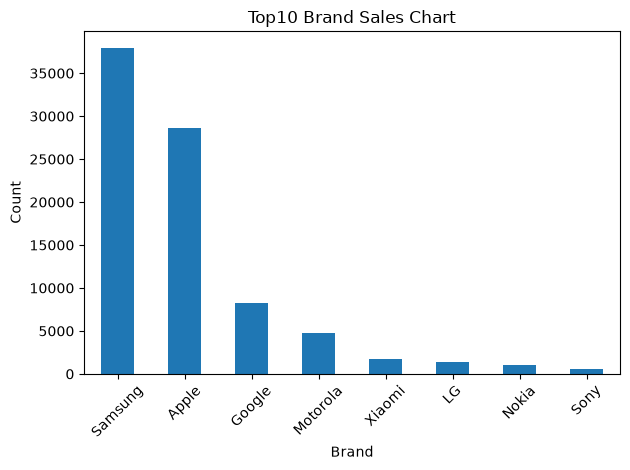

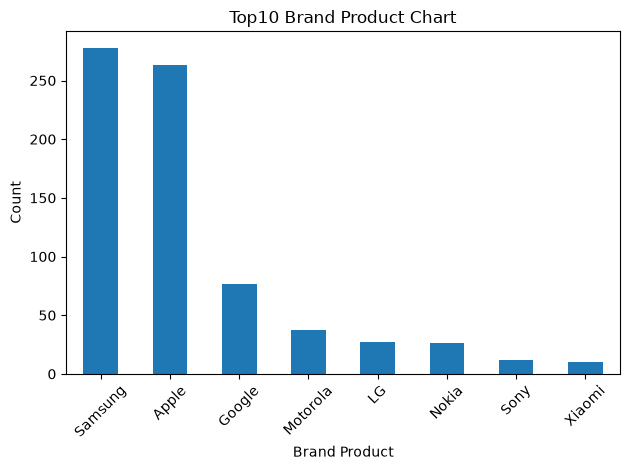

In [ ]:
#top10品牌销售情况、top10品牌商品情况 加 可视化图表

#在查询的结果中看到很多脏数据 像 For Unlock iPhone New 对brand字段列表清洗一下
#计算出品牌数量
BrandSalesTotalNum = ec["brand"].value_counts() #结果输出为 品牌名 数量
#筛选数量大于10的数据 过滤掉脏数据
FilterBrandData = BrandSalesTotalNum[
    BrandSalesTotalNum >= 10
].index
#把筛选出来的值更新到brand字段中
ec = ec[ec["brand"].isin(FilterBrandData)]
#依旧看到有脏数据存在['Samsung', 'Apple', 'New', 'Google', 'Motorola', 'LG', 'Nokia', 'BRAND','For', 'Case', 'Sony', 'Unlocked', 'Xiaomi']
#手工过滤掉
DirtyBrandDataClean = ["New","BRAND","For","Case","Unlocked"]
# 存在这些值就取反 表删除 不存在的取反 保留 ~在python中代表取反
ec = ec[~ec["brand"].isin(DirtyBrandDataClean)]

#统计品牌前10销售情况
Top10BrandSalesNum = (
    #groupby 通过条件分组并返回单一数据结构
    #按照品牌对销量进行分组
    ec.groupby("brand")["sold_quantity (+)"]
    #对某品牌商品销量进行累计求和
    .sum()
    #布尔值列表 默认升序
    .sort_values(ascending=False)
    #销量最高的前10个
    .head(10)
)

#统计品牌商品前10情况
TotalBrandProductNum = (
    #value_counts 计算每个值的出现次数 
    #head(10) 取前10个
   ec["brand"].value_counts().head(10)
)

#品牌销售可视化前10 图
Top10BrandSalesNum.plot(kind="bar")
pltModulePackaging("Top10 Brand Sales Chart","Brand","Count")

#品牌商品可视化前10 图
TotalBrandProductNum.plot(kind="bar")
pltModulePackaging("Top10 Brand Product Chart","Brand Product","Count")


### 4.3 价格区间分析
    用pd.cut() 将商品价格分为了以下区间:
        "0-20"
        "20-50"
        "50-100"
        "100-200"
        "200-500"
    用于分析不同价格段的销售情况

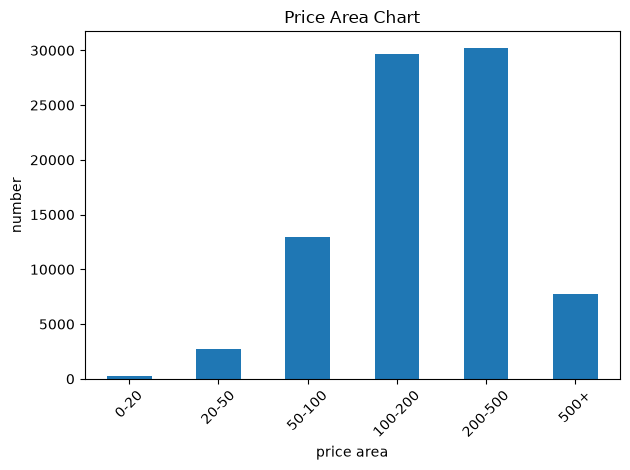

In [ ]:
#价格区间分析

#创建价格区间
PriceAreaBins = [0,20,50,100,200,500,1000]
#价格区域
PriceAreaLabels = ["0-20","20-50","50-100","100-200","200-500","500+"]
#把连续的价格，分成几个价格区间 放到新建的price_range 字段里
ec["price_range"] = pd.cut(
    ec["avg_price"],bins=PriceAreaBins,labels=PriceAreaLabels
) 
PriceAreaSlesToalSum = (
    #把在这个区间内的销售量求和
    ec.groupby("price_range")["sold_quantity (+)"]
    .sum()
    #强制按照这个顺序排列
    .reindex(PriceAreaLabels)
)
#价格区间可视化图表
PriceAreaSlesToalSum.plot(kind="bar")
pltModulePackaging("Price Area Chart","price area","number")


### 4.4 销售与价格关系 散点图 
    更明确展示情况

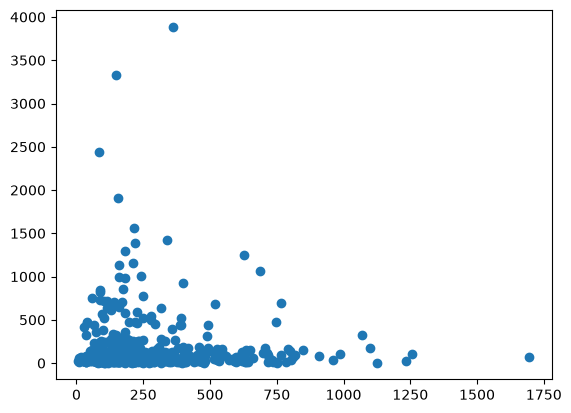

In [ ]:
#销量与价格关系散点图

plt.scatter(
    #x轴 平均价格 y轴 销量
    ec["avg_price"],ec["sold_quantity (+)"]
)

### 4.5 发货国家分析
    看看每个国家的销售情况

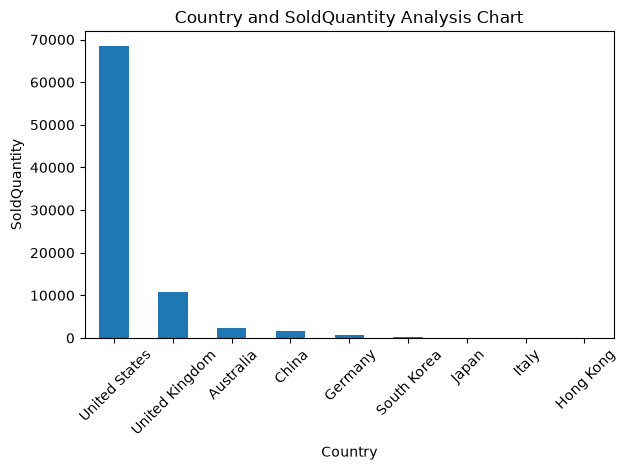

In [ ]:
#发货国家分析

#字段里面出现 from china 去掉from 更美观
ec["shipping from"] = ec["shipping from"].str.replace("from","")
# 将每个国家的销售数据进行累计求和 取前10
CountryAndSoldQunantityAnalysisNum = (
    ec.groupby("shipping from")["sold_quantity (+)"].sum().sort_values(ascending=False).head(10)
)

#画出发货地国家与销售量 可视化图表
CountryAndSoldQunantityAnalysisNum.plot(kind="bar")
plt.xticks(fontsize = 10,ha="center")
pltModulePackaging("Country and SoldQuantity Analysis Chart","Country","SoldQuantity")

### 4.6 前10 热门商品
    看看哪个商品销量最高

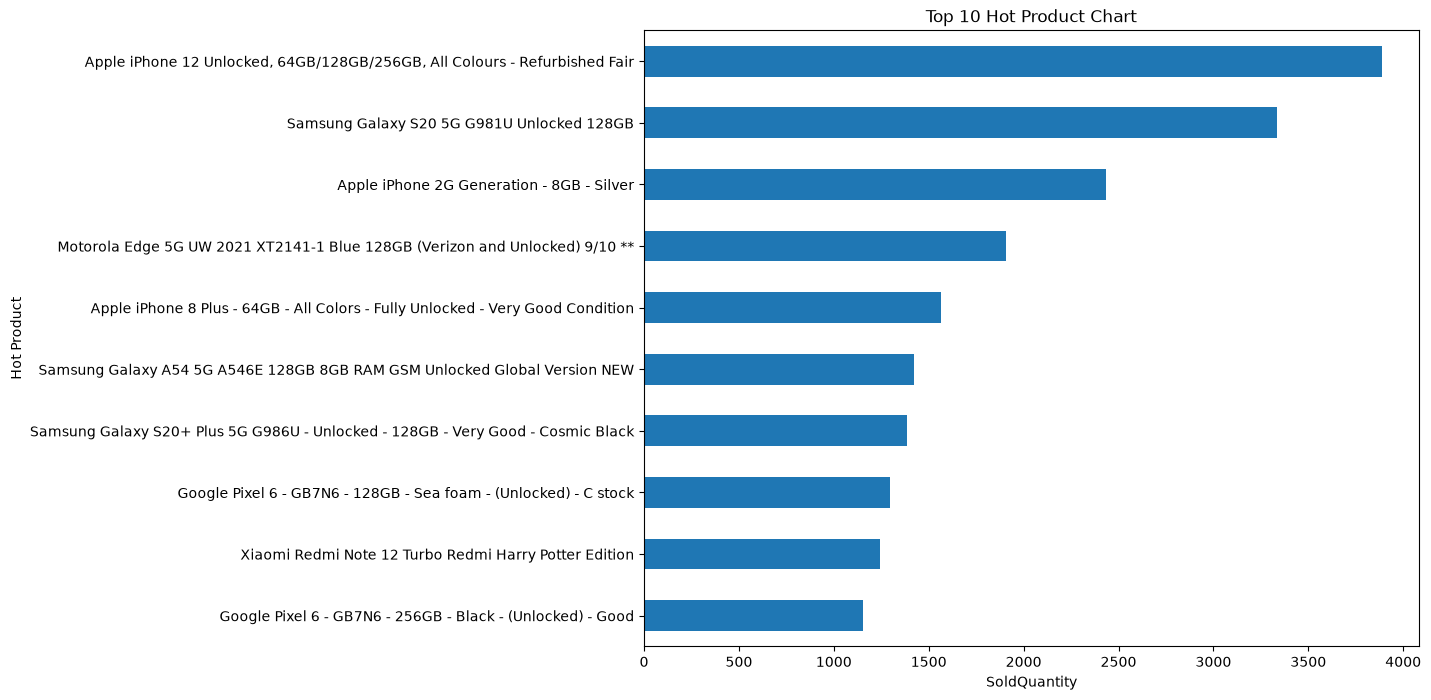

In [ ]:
#前10热门商品

# Top10HotProdoct = (
#     ec.nlargest(10,"sold_quantity (+)").set_index("item_name")
# )

# Top10HotProdoct["sold_quantity (+)"].plot(kind="barh")
#nlargest 选中某个字段值最大的前N条数据 nsmallest() 选中某字段最小的前N条数据
Top10HotProdoct = (
    ec.groupby("item_name")["sold_quantity (+)"]
    .sum()
    #条件N 哪个字段
    .nlargest(10)
    #默认升序
    .sort_values() 
)
#横向柱状图
plt.figure(figsize=(10,8))
Top10HotProdoct.plot(kind="barh")
plt.title("Top 10 Hot Product Chart")
plt.xlabel("SoldQuantity")
plt.ylabel("Hot Product")

plt.show()

### 4.7 品牌平均价格分析

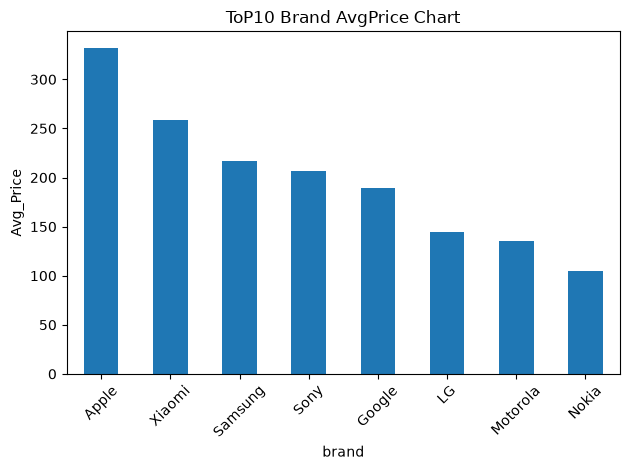

In [ ]:
#品牌平均价格
BrandAvgPrive = (
    ec.groupby("brand")["avg_price"]
    # 计算平均值
    .mean()
    #前10个数值
    .nlargest(10)
)
BrandAvgPrive.plot(kind = "bar")
pltModulePackaging("ToP10 Brand AvgPrice Chart","brand","Avg_Price")

### 4.8 品牌前10 市场份额分析

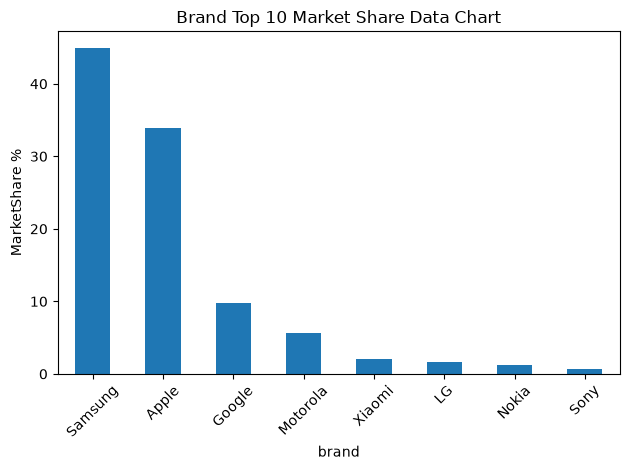

In [ ]:
#品牌前10市场份额

#总销量
TotalSaleProductNum = ec["sold_quantity (+)"].sum()
#品牌总销量
TotalBrandNumber = (
    ec.groupby("brand")["sold_quantity (+)"].sum()
)
#市场份额 品牌总销量 / 总销量 *100 乘100变成百分比制 取最高的10个
MarketShareNum = (
    TotalBrandNumber / TotalSaleProductNum *100
).nlargest(10)
MarketShareNum.plot(kind="bar")
#柱子顶部显示百分比
# ax = MarketShareNum.plot(kind="bar")
# for p in ax.patches:
#     ax.annotate(
#         f'{p.get_height():.1f}%',
#         (p.get_x()+p.get_width()/2,p.get_height()),
#         ha="center"
#     )

pltModulePackaging("Brand Top 10 Market Share Data Chart","brand","MarketShare %")  



## 5. 核心分析
    - 中等价格 200-500 的商品销量最高
    - 大品牌占据主要市场份额 
    - 价格是影响销量的重要因素


## 6.业务建议
    - 重点推广 200 - 500 价格区间商品(这里的价格是美元)
    - 提升头部品牌曝光度
    - 调整高价商品定价策略